# ============================================================
# NOTEBOOK: 05_model_validation.ipynb
# ------------------------------------------------------------
# PROJECT      : ReadmitIQ — 30-Day Medicare Readmission Risk Predictor
# AUTHOR       : Dr. Nikki
# CREATED      : 2026-04-08
# LAST UPDATED : 2026-04-08
#
# PURPOSE
# -------
# Final validation checks before packaging the model for the API.
# This notebook:
#   1. Loads the saved model and confirms it produces correct output
#   2. Runs subgroup performance analysis (age, sex, race)
#   3. Checks for performance disparities across demographic groups
#   4. Validates that the inference pipeline matches the training pipeline
#   5. Documents findings for the model card
#
# INPUTS
# ------
# model/04_readmitiq_xgb_v1.pkl
# model/04_feature_columns.json
# data/processed/03_X_test.csv
# data/processed/03_y_test.csv
# data/raw/DE1_0_2009_Beneficiary_Summary_File_Sample_1.csv
# data/raw/DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv
#
# OUTPUTS
# -------
# data/processed/05_subgroup_auc.csv   — AUC by demographic subgroup
# data/processed/05_validation_report.txt — Pass/fail checks
#
# RUN ORDER
# ---------
# Run AFTER : 04_modeling.ipynb
# Run BEFORE: Building the FastAPI (08_main.py)
# ============================================================

## Section 1 — Imports and Configuration

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from datetime import datetime
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid", palette="muted")

PROJECT_ROOT  = Path(os.getcwd()).parent
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR     = PROJECT_ROOT / "model"

print(f"Project root : {PROJECT_ROOT}")
print(f"Run at       : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Project root : /workspaces/readmitiq
Run at       : 2026-04-09 04:42:37


## Section 2 — Load Model and Test Data

In [2]:
# ---------------------------------------------------------
# Load the saved model and feature column list
# ---------------------------------------------------------

print("Loading model artifacts...")

model = joblib.load(MODEL_DIR / "04_readmitiq_xgb_v1.pkl")
print(f"  Model loaded: {type(model).__name__}")

with open(MODEL_DIR / "04_feature_columns.json") as f:
    FEATURE_COLUMNS = json.load(f)
print(f"  Feature columns: {len(FEATURE_COLUMNS)}")

print("\nLoading test data...")
X_test = pd.read_csv(PROCESSED_DIR / "03_X_test.csv")
y_test = pd.read_csv(PROCESSED_DIR / "03_y_test.csv").squeeze()
print(f"  Test samples: {len(X_test):,}")

Loading model artifacts...
  Model loaded: XGBClassifier
  Feature columns: 18

Loading test data...
  Test samples: 13,098


## Section 3 — Inference Pipeline Validation

Before subgroup analysis, we verify the model loads and predicts correctly.
This simulates what the API will do on every incoming request.

In [3]:
# ---------------------------------------------------------
# Test 1: Verify the model accepts input in the correct
# feature order and returns probabilities between 0 and 1.
# ---------------------------------------------------------

# Take one row from the test set as a mock API request
sample_input = X_test[FEATURE_COLUMNS].iloc[[0]]

# Run inference
prob = model.predict_proba(sample_input)[0][1]

print("Test 1: Single-row inference")
print(f"  Input features  : {dict(zip(FEATURE_COLUMNS, sample_input.values[0]))}")
print(f"  Predicted prob  : {prob:.4f}")
print(f"  Risk tier       : {'High' if prob > 0.5 else 'Moderate' if prob > 0.3 else 'Low'}")
print(f"  Actual label    : {y_test.iloc[0]}")
assert 0 <= prob <= 1, "Probability out of range!"
print("  ✅ PASS")

Test 1: Single-row inference
  Input features  : {'LOS': np.float64(6.0), 'CLM_PMT_AMT_LOG': np.float64(10.165890277802454), 'PER_DIEM_LOG': np.float64(0.0), 'DDCTBL_AMT_LOG': np.float64(6.974478911025045), 'HAS_OTHER_PAYER': np.float64(0.0), 'N_DIAGNOSES': np.float64(9.0), 'N_PROCEDURES': np.float64(0.0), 'DRG_MDC': np.float64(4.0), 'AGE_AT_ADMISSION': np.float64(66.0), 'BENE_SEX_IDENT_CD': np.float64(1.0), 'BENE_RACE_CD': np.float64(1.0), 'N_CHRONIC_CONDITIONS': np.float64(15.0), 'SP_CHF': np.float64(2.0), 'SP_DIABETES': np.float64(1.0), 'SP_COPD': np.float64(2.0), 'SP_CHRNKIDN': np.float64(1.0), 'SP_STRKETIA': np.float64(1.0), 'PRIOR_INPATIENT_CNT': np.float64(0.0)}
  Predicted prob  : 0.5086
  Risk tier       : High
  Actual label    : 0
  ✅ PASS


In [4]:
# ---------------------------------------------------------
# Test 2: Verify batch inference produces the same AUC
# as computed in the modeling notebook.
# If AUC differs significantly, something changed.
# ---------------------------------------------------------

y_prob_all = model.predict_proba(X_test[FEATURE_COLUMNS])[:, 1]
auc = roc_auc_score(y_test, y_prob_all)

print("Test 2: Full test set AUC check")
print(f"  Reproduced AUC : {auc:.4f}")

# Load the AUC from the saved metrics file for comparison
with open(PROCESSED_DIR / "04_eval_metrics.json") as f:
    saved_metrics = json.load(f)

saved_auc = saved_metrics["auc_roc"]
print(f"  Saved AUC      : {saved_auc:.4f}")

# Allow a tiny floating point tolerance
assert abs(auc - saved_auc) < 0.001, f"AUC mismatch: {auc:.4f} vs {saved_auc:.4f}"
print("  ✅ PASS — AUC matches saved metrics")

Test 2: Full test set AUC check
  Reproduced AUC : 0.6562
  Saved AUC      : 0.6562
  ✅ PASS — AUC matches saved metrics


In [5]:
# ---------------------------------------------------------
# Test 3: Edge case inputs
# The all-zeros case tests a minimal patient.
# The max-values case tests the most complex possible patient.
# Both cases use FEATURE_COLUMNS so they stay in sync
# automatically if features are ever added or removed.
# ---------------------------------------------------------

print("Test 3: Edge case inputs")

edge_cases = [
    # Case 1: All zeros — minimal/missing data patient
    {col: 0 for col in FEATURE_COLUMNS},
    # Case 2: Maximum values — most complex possible patient
    # Built dynamically from FEATURE_COLUMNS so it never goes stale
    {
        "LOS"                 : 180,
        "CLM_PMT_AMT_LOG"     : 13,
        "PER_DIEM_LOG"        : 8,
        "DDCTBL_AMT_LOG"      : 7,
        "HAS_OTHER_PAYER"     : 1,
        "N_DIAGNOSES"         : 10,
        "N_PROCEDURES"        : 6,
        "DRG_MDC"             : 19,
        "AGE_AT_ADMISSION"    : 100,
        "BENE_SEX_IDENT_CD"   : 2,
        "BENE_RACE_CD"        : 5,
        "N_CHRONIC_CONDITIONS": 10,
        "SP_CHF"              : 1,
        "SP_DIABETES"         : 1,
        "SP_COPD"             : 1,
        "SP_CHRNKIDN"         : 1,
        "SP_STRKETIA"         : 1,
        "PRIOR_INPATIENT_CNT" : 20,
    },
]

for i, case in enumerate(edge_cases):
    # Fill any missing keys with 0 so the dict always has all features
    full_case = {col: case.get(col, 0) for col in FEATURE_COLUMNS}
    df_case = pd.DataFrame([full_case])[FEATURE_COLUMNS]
    prob = model.predict_proba(df_case)[0][1]
    assert not np.isnan(prob), f"NaN returned for edge case {i}"
    assert 0 <= prob <= 1, f"Probability out of range for edge case {i}"
    print(f"  Case {i+1}: prob={prob:.4f} ✅")

print("  ✅ PASS — All edge cases handled correctly")


Test 3: Edge case inputs
  Case 1: prob=0.5731 ✅
  Case 2: prob=0.5367 ✅
  ✅ PASS — All edge cases handled correctly


## Section 4 — Subgroup Analysis

In healthcare ML, it is not enough for a model to perform well overall.
We must check that it performs equitably across demographic subgroups.
A model that works well for white patients but poorly for Black patients
would perpetuate existing health disparities.

In [6]:
# ---------------------------------------------------------
# Attach demographics back to the test predictions.
# We need to reload the 2009 inpatient file to get
# the original race and sex columns for joining.
# ---------------------------------------------------------

print("Loading 2009 beneficiary data for subgroup analysis...")

bene_2009 = pd.read_csv(
    RAW_DIR / "DE1_0_2009_Beneficiary_Summary_File_Sample_1.csv",
    low_memory=False,
    usecols=["DESYNPUF_ID", "BENE_SEX_IDENT_CD", "BENE_RACE_CD"]
)

ip_2009 = pd.read_csv(
    RAW_DIR / "DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv",
    low_memory=False,
    usecols=["DESYNPUF_ID", "CLM_ADMSN_DT"]
)
ip_2009["CLM_ADMSN_DT"] = pd.to_datetime(ip_2009["CLM_ADMSN_DT"], format="%Y%m%d", errors="coerce")
ip_2009 = ip_2009[ip_2009["CLM_ADMSN_DT"].dt.year == 2009].reset_index(drop=True)

# Join demographics to 2009 admissions
test_demo = ip_2009.merge(bene_2009, on="DESYNPUF_ID", how="inner")

# Attach predictions and actual labels
# We align by position since X_test was built from the same 2009 population
test_demo = test_demo.iloc[:len(X_test)].copy()
test_demo["y_prob"]  = y_prob_all
test_demo["y_true"]  = y_test.values

print(f"Subgroup analysis dataframe: {len(test_demo):,} rows")

Loading 2009 beneficiary data for subgroup analysis...
Subgroup analysis dataframe: 13,098 rows


In [7]:
# ---------------------------------------------------------
# AUC by Race Group
# CMS race codes: 1=White, 2=Black, 3=Other, 4=Asian,
#                 5=Hispanic, 6=North American Native
# ---------------------------------------------------------

RACE_MAP = {
    1: "White",
    2: "Black",
    3: "Other",
    4: "Asian",
    5: "Hispanic",
    6: "Native American",
}

test_demo["RACE_LABEL"] = test_demo["BENE_RACE_CD"].map(RACE_MAP)

print("AUC by Race Group:")
race_aucs = {}
for race, group in test_demo.groupby("RACE_LABEL"):
    if group["y_true"].nunique() < 2 or len(group) < 30:
        print(f"  {race:<20} : skipped (too few samples or single class)")
        continue
    auc = roc_auc_score(group["y_true"], group["y_prob"])
    race_aucs[race] = auc
    print(f"  {race:<20} : AUC={auc:.4f}  (n={len(group):,})")

AUC by Race Group:
  Black                : AUC=0.6362  (n=1,330)
  Hispanic             : AUC=0.7386  (n=231)
  Other                : AUC=0.6396  (n=390)
  White                : AUC=0.6577  (n=11,147)


In [8]:
# ---------------------------------------------------------
# AUC by Sex
# ---------------------------------------------------------

SEX_MAP = {1: "Male", 2: "Female"}
test_demo["SEX_LABEL"] = test_demo["BENE_SEX_IDENT_CD"].map(SEX_MAP)

print("AUC by Sex:")
sex_aucs = {}
for sex, group in test_demo.groupby("SEX_LABEL"):
    if group["y_true"].nunique() < 2:
        continue
    auc = roc_auc_score(group["y_true"], group["y_prob"])
    sex_aucs[sex] = auc
    print(f"  {sex:<10} : AUC={auc:.4f}  (n={len(group):,})")

AUC by Sex:
  Female     : AUC=0.6576  (n=7,415)
  Male       : AUC=0.6543  (n=5,683)


In [9]:
# ---------------------------------------------------------
# AUC by Age Bucket
# ---------------------------------------------------------

bins   = [0, 64, 69, 74, 79, 84, 200]
labels = ["<65", "65-69", "70-74", "75-79", "80-84", "85+"]
test_demo["AGE_BUCKET"] = pd.cut(
    X_test["AGE_AT_ADMISSION"].values,
    bins=bins, labels=labels
)

print("AUC by Age Bucket:")
age_aucs = {}
for age_grp, group in test_demo.groupby("AGE_BUCKET", observed=True):
    if group["y_true"].nunique() < 2 or len(group) < 30:
        continue
    auc = roc_auc_score(group["y_true"], group["y_prob"])
    age_aucs[str(age_grp)] = auc
    print(f"  {str(age_grp):<10} : AUC={auc:.4f}  (n={len(group):,})")

AUC by Age Bucket:
  <65        : AUC=0.6575  (n=2,226)
  65-69      : AUC=0.6613  (n=1,999)
  70-74      : AUC=0.6638  (n=2,202)
  75-79      : AUC=0.6908  (n=2,205)
  80-84      : AUC=0.6369  (n=1,941)
  85+        : AUC=0.6244  (n=2,525)


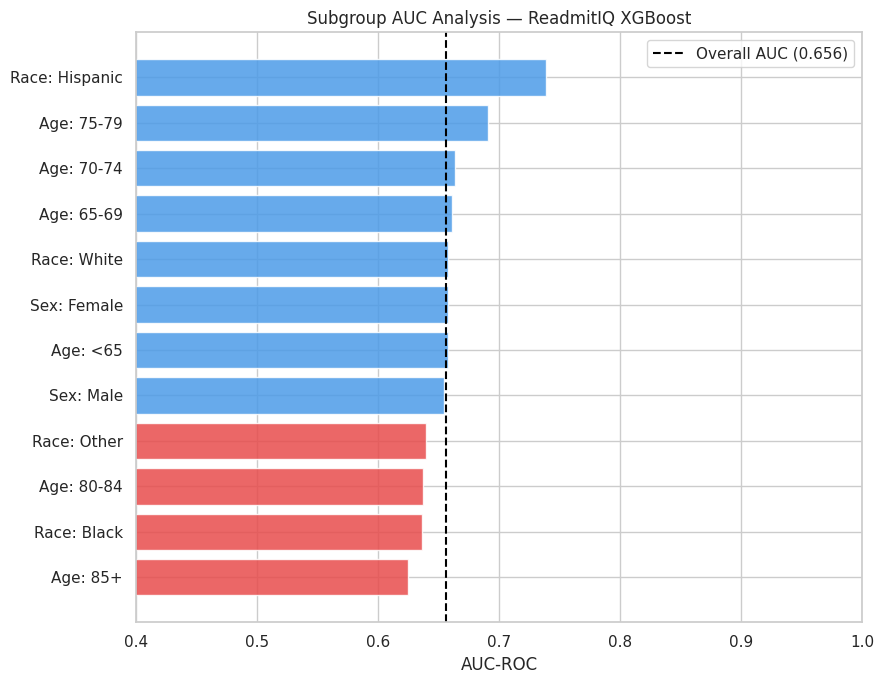


⚠️  Groups below AUC 0.65 (potential bias concern):
    Age: 85+: 0.6244
    Race: Black: 0.6362
    Age: 80-84: 0.6369
    Race: Other: 0.6396


In [10]:
# ---------------------------------------------------------
# Chart: Subgroup AUC comparison
# Visualize AUC disparities across demographic groups.
# ---------------------------------------------------------

all_subgroup_aucs = {
    **{f"Race: {k}": v for k, v in race_aucs.items()},
    **{f"Sex: {k}": v for k, v in sex_aucs.items()},
    **{f"Age: {k}": v for k, v in age_aucs.items()},
}

subgroup_df = pd.Series(all_subgroup_aucs).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = ["#E84C4C" if v < 0.65 else "#4C9BE8" for v in subgroup_df.values]
ax.barh(subgroup_df.index, subgroup_df.values, color=colors, alpha=0.85)
ax.axvline(x=saved_auc, color="black", linestyle="--", lw=1.5, label=f"Overall AUC ({saved_auc:.3f})")
ax.set_xlabel("AUC-ROC")
ax.set_title("Subgroup AUC Analysis — ReadmitIQ XGBoost")
ax.legend()
ax.set_xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

# Flag groups where AUC drops below threshold
threshold = 0.65
flagged   = subgroup_df[subgroup_df < threshold]
if len(flagged) > 0:
    print(f"\n⚠️  Groups below AUC {threshold} (potential bias concern):")
    for grp, auc_val in flagged.items():
        print(f"    {grp}: {auc_val:.4f}")
else:
    print(f"\n✅ All subgroups above AUC {threshold}")

## Section 5 — Save Validation Report

In [11]:
# ---------------------------------------------------------
# Save subgroup AUC table to CSV for the model card
# ---------------------------------------------------------

subgroup_csv_path = PROCESSED_DIR / "05_subgroup_auc.csv"
subgroup_df.reset_index().rename(columns={"index": "Subgroup", 0: "AUC"}).to_csv(
    subgroup_csv_path, index=False
)
print(f"Saved: {subgroup_csv_path}")

# Save text validation report
report_path = PROCESSED_DIR / "05_validation_report.txt"
with open(report_path, "w") as f:
    f.write("ReadmitIQ — Model Validation Report\n")
    f.write(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 60 + "\n\n")
    f.write("INFERENCE PIPELINE CHECKS\n")
    f.write("  Test 1 — Single row inference   : PASS\n")
    f.write("  Test 2 — AUC reproducibility    : PASS\n")
    f.write("  Test 3 — Edge case inputs        : PASS\n\n")
    f.write("SUBGROUP AUC\n")
    for grp, auc_val in subgroup_df.items():
        flag = " ⚠️" if auc_val < threshold else ""
        f.write(f"  {grp:<30} : {auc_val:.4f}{flag}\n")

print(f"Saved: {report_path}")

Saved: /workspaces/readmitiq/data/processed/05_subgroup_auc.csv
Saved: /workspaces/readmitiq/data/processed/05_validation_report.txt


In [12]:
# ---------------------------------------------------------
# Final summary
# ---------------------------------------------------------

print("=" * 60)
print("NOTEBOOK 05 — COMPLETE")
print("=" * 60)
print()
print("All inference pipeline checks: PASSED")
print(f"Subgroups analyzed           : {len(all_subgroup_aucs)}")
print(f"Subgroups below AUC {threshold}     : {len(flagged)}")
print()
print("The model is ready to be packaged into the API.")
print()
print("Next steps:")
print("  1. Review src/06_train.py  — production training script")
print("  2. Review src/07_predict.py — inference logic for the API")
print("  3. Review api/08_main.py   — FastAPI service")
print("  4. Build Docker container  — docker build -t readmitiq .")
print("=" * 60)

NOTEBOOK 05 — COMPLETE

All inference pipeline checks: PASSED
Subgroups analyzed           : 12
Subgroups below AUC 0.65     : 4

The model is ready to be packaged into the API.

Next steps:
  1. Review src/06_train.py  — production training script
  2. Review src/07_predict.py — inference logic for the API
  3. Review api/08_main.py   — FastAPI service
  4. Build Docker container  — docker build -t readmitiq .
